# 2 - Bài toán phân loại (gồm phân Binary và Categories)
* Đoán về tính đúng sai (True or False)
* Nhận dạng vật thể xác định nó như là xác định món ăn (cơm phở cháo)

## 1. Chuẩn bị dữ liệu cho bài toán phân loại.

In [1]:
import sklearn
from sklearn.datasets import make_circles


n_sample = 1000

X,y = make_circles(n_samples=n_sample, noise=0.03, random_state=42)

len(X),len(y)

(1000, 1000)

In [2]:
X[:5], y[:5]
X.shape

(1000, 2)

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

circles = pd.DataFrame({"X1": X[:,0], "X2" : X[:,1], "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [4]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

### Visualize Trực quan hóa dữ liệu để quan sát

In [5]:
len(X[:,0])

1000

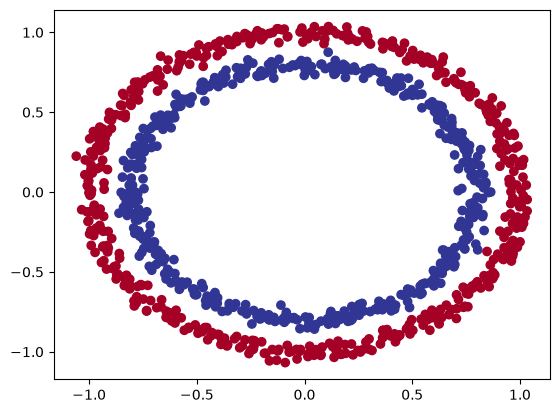

In [6]:
plt.scatter(x=X[:,0], y=X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [9]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Đưa data về tensor và chia bộ train và test

In [10]:
import torch

import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)


X[:5],y[:5]


(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
# Split data into training and testing set
torch.manual_seed(42)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## Building a model
Tạo một model phân biệt chấm nào nằm trong chấm nào nằm ngoài
Các bước thực hiện:
1. Khởi tạo device là gpu để tính toán nhanh hơn nếu có (không thì dùng cpu).
2. Kiến trúc của mô hình dùng vào class base là nn.Module
3. Định nghĩa hàm loss funct và hàm tối ưu (optimizer)
4. Train & Test block in a loop

In [12]:
import torch
from torch import nn

# Make a device

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [13]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Dựng model thuiiiii @@ theo step:
1. Subclass là `nn.Module` hầu như các cu tí mô hình đều đi từ base class ni.
2. Create 2 `nn.Linear() ` các layer ni phụ trác thay máy tính thay đổi cách nó nhìn hình dạng dữ liệu của mình.
3. Định nghĩa `forward` 
4. Khởi tạo mô hình và gắn gpu dô

In [14]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # Khởi tạo 2 linear layers
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # GG Search neuron net work sẽ thấy có 2 node input và các node trước output là hidden node
        # Việc tăng các node hidden lên là mình sẽ tạo cho mô hình có thêm cơ hội học tập sau đó ở layer cuối cùng mình sẽ gộp lại thành output cần thiết
        # Lưu ý là output feature trước phải match up với input feature sau.
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # Trả về cùng shape với labels
        #Định nghĩa hàm forward
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) #x--> layer_1 --> layer_2 --> output

#Instance model
model_0 = CircleModelV0().to(device)

model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [15]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [16]:
# Replicate CircleModelV0 with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")    

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Set up loss func amd optimizer
Ví dụ với Hồi quy tuyến tính thì mình dùng MSE hoặc  MAE để tính sai số mất mát và optimizer
Thì với classification sẽ dùng BinaryCrossentropy cho phân loại nhị phân hoặc Crossentropy cho phân loại nhiều giá trị label hơn

In [18]:
# loss_fn = nn.BCELoss() dùng dòng này khi dữ liệu đã đi qua hàm sigmoid trước khi dữ liệu đi vô BCELoss()


loss_fn = nn.BCEWithLogitsLoss() # Đưa dữ liệu vô hàm sigmoid rồi vô BCELoss nói chung là gộp cả 2 vô làm 1 bước.

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)


In [19]:
# Calculate accuracy

def accuracy_fn (y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


### 3. Train model

để huấn luyện model:
1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward
5. Optimize step 


### 3.1 Going from raw logit -> prediction probabilities -> prediction labels
Dữ liệu đầu ra sẽ là dữ liệu raw **logits**
Có thể chuyển **logits** thành prediction probabilities bằng đưa chúng vào các activation func (sigmoil or softmax etc...)

Sau đó đưa những dự đoán này thành **prediction labels** bằng cách làm tròn hoặc argmax

In [20]:
# Xem 5 ouput đầu tiên của forward data
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]

y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [21]:
# Use the sigmoid activation

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [22]:
#find prediction label
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.sigmoid(model_0(X_test.to(device))[:5])

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid

y_preds.squeeze()

tensor([False, False, False, False, False], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

### 3.2 Buidling a training and testing loop

In [23]:
torch.manual_seed(42)


torch.cuda.manual_seed(42)

# Set the number epochs

epochs = 100

#put data to target device

X_train, y_train = X_train.to(device), y_train.to(device)

X_test, y_test = X_test.to(device), y_test.to(device)

# Build train and test loop

for epoch in range(epochs):
    
    ### Training
    model_0.train()

    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits --> pred probs --> pred label


    #2. Calculate the loss
    # loss = loss_fn(torch.sigmoid(y_logits)) # dùng BCELoss vì mình phải thêm sigmoid thủ công
    loss = loss_fn(y_logits, y_train) # dùng để gộp bước đưa dữ liệu qua hàm sigmoid BCEWithLogitsLoss()

    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)


    #3 Optimizer zero grad
    optimizer.zero_grad()

    #4 Loss backward
    loss.backward()

    #5 Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()

    with torch.inference_mode():

        # 1 Do forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2 Calculate test loss / accuracy

        test_loss = loss_fn(test_logits, y_test)

        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

# Print infomaiton
    if epoch % 10 ==0:
        print(f'Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%')




Epoch: 0 | Loss: 0.69796 | Accuracy: 51.88% | Test Loss: 0.69440 | Test Accuracy: 58.00%
Epoch: 10 | Loss: 0.69590 | Accuracy: 51.25% | Test Loss: 0.69305 | Test Accuracy: 53.00%
Epoch: 20 | Loss: 0.69490 | Accuracy: 51.62% | Test Loss: 0.69254 | Test Accuracy: 49.50%
Epoch: 30 | Loss: 0.69435 | Accuracy: 51.12% | Test Loss: 0.69236 | Test Accuracy: 49.50%
Epoch: 40 | Loss: 0.69401 | Accuracy: 50.88% | Test Loss: 0.69232 | Test Accuracy: 51.00%
Epoch: 50 | Loss: 0.69378 | Accuracy: 50.25% | Test Loss: 0.69234 | Test Accuracy: 50.00%
Epoch: 60 | Loss: 0.69362 | Accuracy: 50.00% | Test Loss: 0.69239 | Test Accuracy: 51.50%
Epoch: 70 | Loss: 0.69351 | Accuracy: 50.25% | Test Loss: 0.69246 | Test Accuracy: 51.00%
Epoch: 80 | Loss: 0.69342 | Accuracy: 49.88% | Test Loss: 0.69254 | Test Accuracy: 50.00%
Epoch: 90 | Loss: 0.69336 | Accuracy: 49.88% | Test Loss: 0.69262 | Test Accuracy: 53.00%


## 4. Make prediction and evaluate model

In [24]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


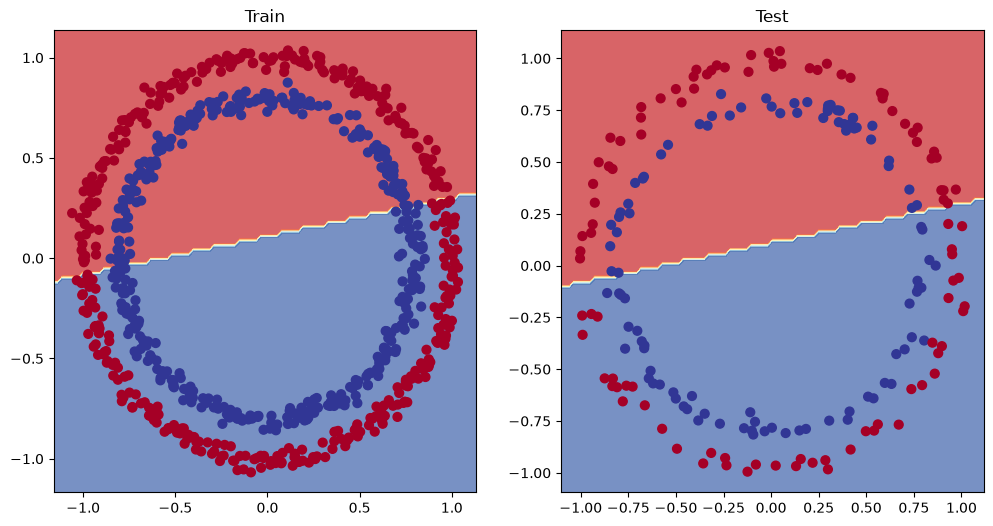

In [25]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_0,X_train,y_train)

plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_0,X_test,y_test)

## 5. Improve model
* Thêm nhiều layer hơn  
* Nhiều hidden unit hơn 
* Huấn luyện lâu hơn
* Đổi activation func
* Đổi lr

Thử các phương án như:
* Thay đổi các hidden unit từ 5 thành 10
* Tăng layer lên 2 thành 3
* Sô lượng loop (epochs ) 100 -> 1000

In [26]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0849, -0.2762],
                      [ 0.4610, -0.5187],
                      [-0.3271, -0.1947],
                      [-0.4220,  0.0507],
                      [-0.7016,  0.6600]])),
             ('0.bias', tensor([-0.6060,  0.5246,  0.1149, -0.2211,  0.4275])),
             ('1.weight',
              tensor([[ 0.0741,  0.2406,  0.0222, -0.1075,  0.1965]])),
             ('1.bias', tensor([-0.1888]))])

In [27]:
X_train[:5], y_train[:5 ]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]], device='cuda:0'),
 tensor([1., 0., 0., 0., 1.], device='cuda:0'))

In [28]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
    def forward(self, x):
        z = self.layer_1(x)
        z = self.layer_2(z)
        z = self.layer_3(z)
        return z

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [29]:
# Tạo hàm mất mát

loss_fn = nn.BCEWithLogitsLoss()

# Tạo hàm optimizer

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)


In [30]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)

epochs = 1000
#Put data to gpu
X_train,y_train = X_train.to(device), y_train.to(device)

X_test, y_test = X_test.to(device), y_test.to(device)


for epoch in range(epochs):
### Training
    model_1.train()

    #1 forward pass
    y_logits = model_1(X_train).squeeze()

    y_pred = torch.round(torch.sigmoid(y_logits))
    #2Calculate the loss / accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    #3 optimize zero grad
    optimizer.zero_grad()

    #4 loss backward
    loss.backward()
    #5 optimize step

    optimizer.step()

### Testing

    model_1.eval()
    with torch.inference_mode():
        #1 do forward
        test_logits = model_1(X_test).squeeze()
        
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        #2 calculate the loss / accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

        #Print information
    if epoch % 100 == 0:
        print(f'Epochs: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%')

Epochs: 0 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epochs: 100 | Loss: 0.69305 | Accuracy: 50.38% | Test Loss: 0.69379 | Test Accuracy: 48.00%
Epochs: 200 | Loss: 0.69299 | Accuracy: 51.12% | Test Loss: 0.69437 | Test Accuracy: 46.00%
Epochs: 300 | Loss: 0.69298 | Accuracy: 51.62% | Test Loss: 0.69458 | Test Accuracy: 45.00%
Epochs: 400 | Loss: 0.69298 | Accuracy: 51.12% | Test Loss: 0.69465 | Test Accuracy: 46.00%
Epochs: 500 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69467 | Test Accuracy: 46.00%
Epochs: 600 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epochs: 700 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epochs: 800 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epochs: 900 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%


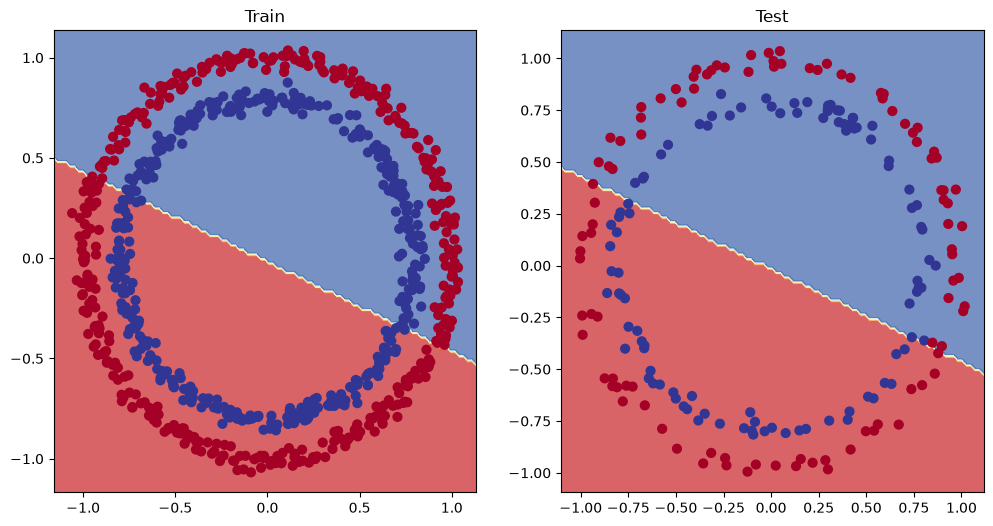

In [31]:
#Plot boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_1,X_train,y_train)

plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_1,X_test,y_test)


## 5.1 Chuẩn bị dữ liệu if mô hình có thể học từ đường thằng

In [32]:
weight = 0.7
bias = 0.3

X_regression = torch.arange(0,1,0.01).unsqueeze(dim=1)


y_regression = X_regression*weight + bias

print(len(X_regression))

X_regression[:5],y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [33]:
split_size = int(len(y_regression)*0.8)

X_train_regression, y_train_regression = X_regression[:split_size], y_regression[:split_size]

X_test_regression, y_test_regression = X_regression[split_size:], y_regression[split_size:]

len(X_train_regression),len(X_test_regression),len(y_train_regression),len(y_test_regression), 

(80, 20, 80, 20)

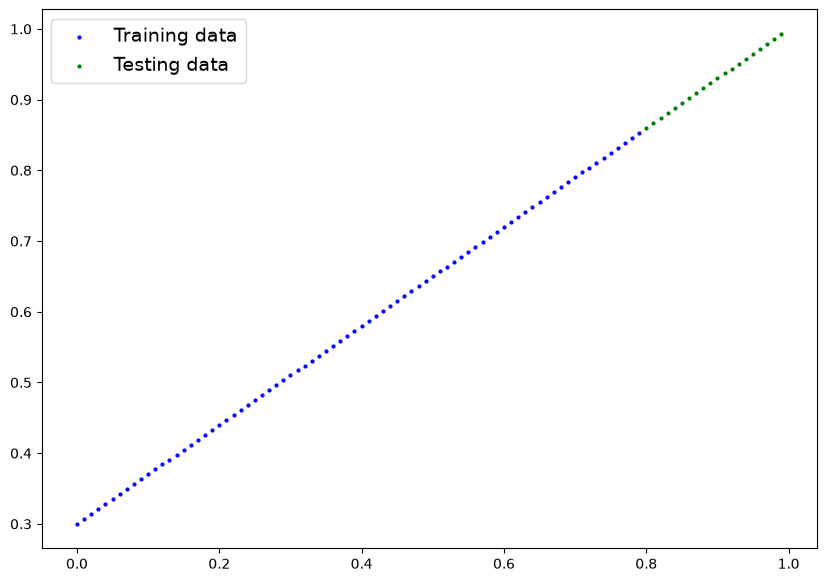

In [34]:
plot_predictions(X_train_regression, y_train_regression, X_test_regression, y_test_regression)

### 5.2 Adjusting `model_1` to fit a straight line  

In [35]:
# Same architecture as a model 1 but using Sequential
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10 , out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [36]:
# Loss and optimizer

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)


In [39]:
# train model

torch.manual_seed(42)

torch.cuda.manual_seed(42)

epochs = 1000

# Put data to gpu
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)

X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):

    model_2.train()

    y_pred = model_2(X_train_regression)

    loss = loss_fn(y_pred, y_train_regression)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    ## Test

    model_2.eval()
    with torch.inference_mode():
        test_preds = model_2(X_test_regression)

        test_loss = loss_fn(test_preds, y_test_regression)

    #Print infomaiton
    if epoch % 100 == 0:
        print(f'Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}')


Epoch: 0 | Loss: 0.01782 | Test Loss: 0.00333
Epoch: 100 | Loss: 0.01674 | Test Loss: 0.00317
Epoch: 200 | Loss: 0.01640 | Test Loss: 0.00316
Epoch: 300 | Loss: 0.01648 | Test Loss: 0.00256
Epoch: 400 | Loss: 0.01648 | Test Loss: 0.00323
Epoch: 500 | Loss: 0.01632 | Test Loss: 0.00337
Epoch: 600 | Loss: 0.01597 | Test Loss: 0.00284
Epoch: 700 | Loss: 0.01458 | Test Loss: 0.00244
Epoch: 800 | Loss: 0.01532 | Test Loss: 0.00275
Epoch: 900 | Loss: 0.01406 | Test Loss: 0.00288


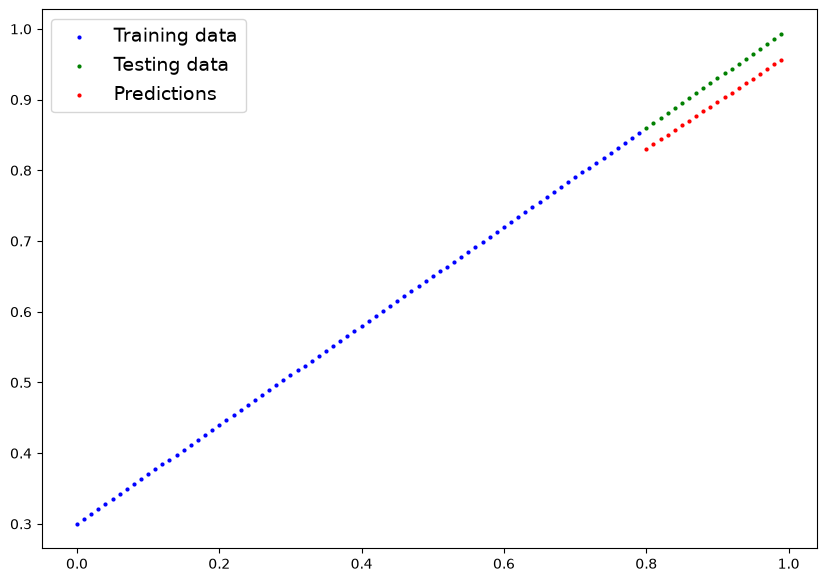

In [40]:
#  Turn on evaluation
model_2.eval()

with torch.inference_mode():
    y_pred  = model_2(X_test_regression)

plot_predictions(X_train_regression.cpu(), y_train_regression.cpu(), X_test_regression.cpu(), y_test_regression.cpu(), predictions=y_pred.cpu())

## 6. Trang bị vũ khí để mô hình có thể đọc được dữ liệu non linear

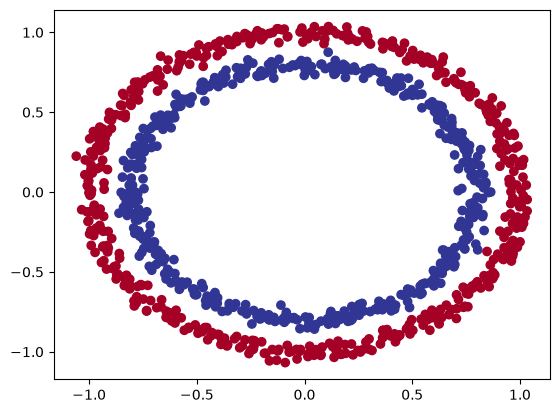

In [41]:
# Make and plot data 

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000
X,y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [42]:
# Chuyển data to tensor và chia train test split
import torch
from sklearn.model_selection import train_test_split

#Turn data into tensor
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)


X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity
* Linear là đường thẳng tắp
* non-linear ờ đúng r đó nhìn gì =)) nó không thẳng hihi

In [43]:
from torch import  nn

class CircleModelV2 (nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))


model_3 = CircleModelV2().to(device)

model_3


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [44]:
# Set up loss and optimizer

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

    

### 6.3 Training a model non-linearity

In [47]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs =1000

for epoch in range (epochs):
    ### Training 
    model_3.train()

    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Testing
    model_3.eval()

    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()

        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)
    if epoch % 100 ==0:
        print(f'Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%')
    

 

Loss: 0.69295 | Accuracy: 50.00% | Test Loss: 0.69319 | Test Accuracy: 50.00%
Loss: 0.69115 | Accuracy: 52.88% | Test Loss: 0.69102 | Test Accuracy: 52.50%
Loss: 0.68977 | Accuracy: 53.37% | Test Loss: 0.68940 | Test Accuracy: 55.00%
Loss: 0.68795 | Accuracy: 53.00% | Test Loss: 0.68723 | Test Accuracy: 56.00%
Loss: 0.68517 | Accuracy: 52.75% | Test Loss: 0.68411 | Test Accuracy: 56.50%
Loss: 0.68102 | Accuracy: 52.75% | Test Loss: 0.67941 | Test Accuracy: 56.50%
Loss: 0.67515 | Accuracy: 54.50% | Test Loss: 0.67285 | Test Accuracy: 56.00%
Loss: 0.66659 | Accuracy: 58.38% | Test Loss: 0.66322 | Test Accuracy: 59.00%
Loss: 0.65160 | Accuracy: 64.00% | Test Loss: 0.64757 | Test Accuracy: 67.50%
Loss: 0.62362 | Accuracy: 74.00% | Test Loss: 0.62145 | Test Accuracy: 79.00%


### 6.4 Evaluating a model trained with non-linearity activation func

In [48]:
#Make prediction
model_3.eval()

with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

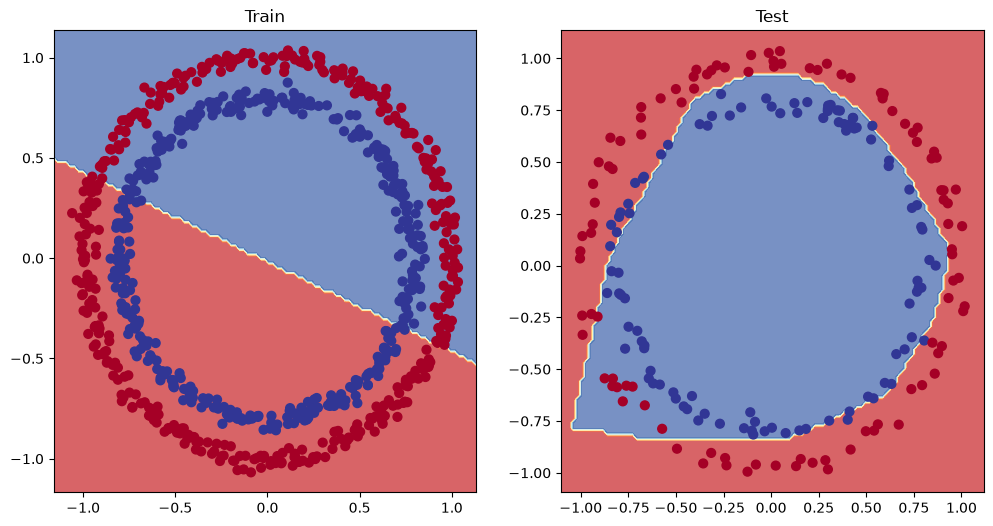

In [50]:
#Plot boundary
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_1,X_train,y_train)

plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_3,X_test, y_test)

## 7. Replicating non-linear activation func
Với mạng neuron, Chúng ta nên đưa nó `công cụ` để nó khám phá kiểu (các dạng tuyến tính, không tuyến tính ,...) hơn là bảo nó học một cách vô định (kiểu đoán í)

Những công cụ đó là `non linear func` https://docs.pytorch.org/docs/2.13/nn.html#non-linear-activations-other

In [52]:
A = torch.arange(-10,10,1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

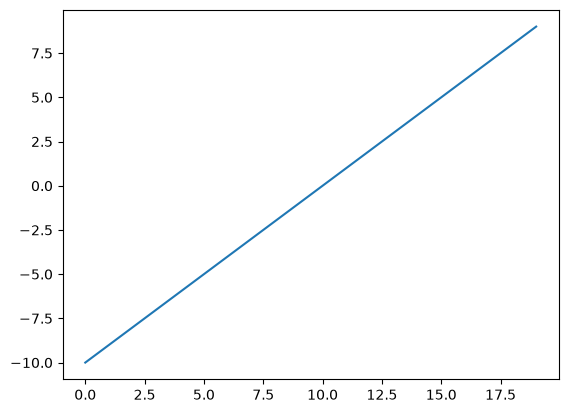

In [53]:
#Visualize this data
plt.plot(A)

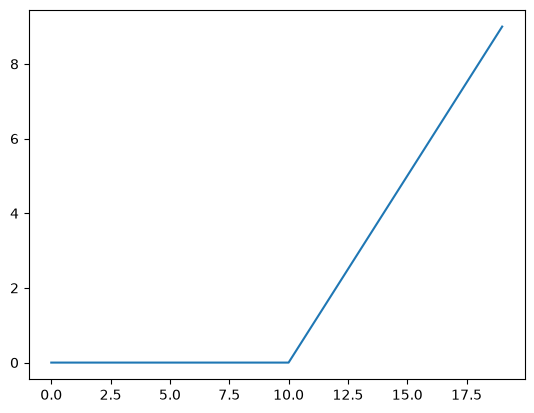

In [54]:
plt.plot(torch.relu(A))

In [60]:
def my_relu (x: torch.Tensor) -> torch.Tensor :
    return torch.maximum(torch.tensor(0), x)

In [61]:
my_relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

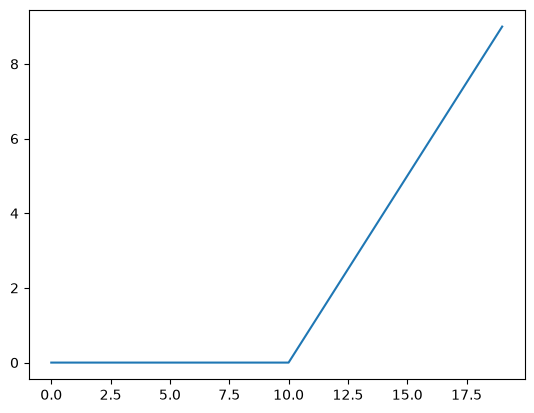

In [62]:
plt.plot(my_relu(A))

In [63]:
def my_sigmoid (x:torch.Tensor) -> torch.Tensor:
    return 1 / (1 + torch.exp(-x))

my_sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

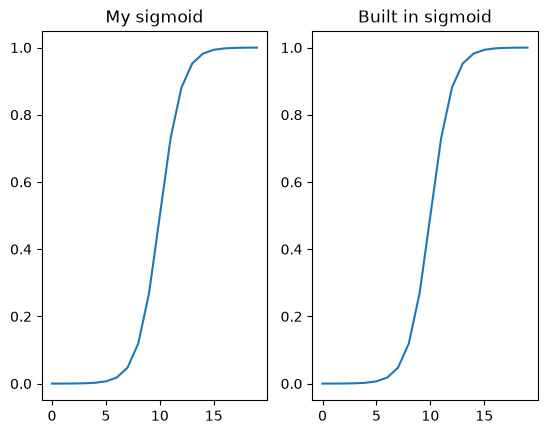

In [64]:
plt.subplot(1,2,1)
plt.title('My sigmoid')
plt.plot(my_sigmoid(A))
plt.subplot(1,2,2)
plt.title('Built in sigmoid')
plt.plot(torch.sigmoid(A))


# 8. Putting knownledge together with a multi-class classification

*Binary classification its mean is true or false / Yes or No
*Multi classification its mean more than one things

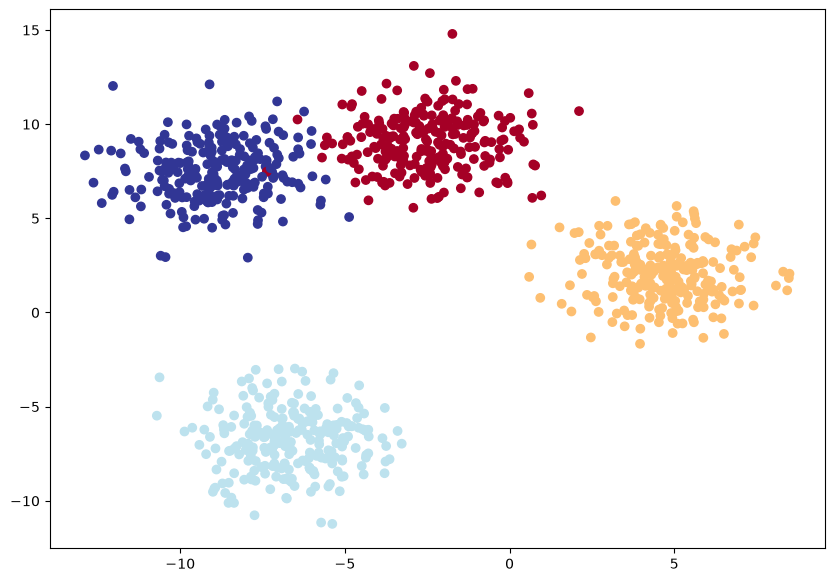

In [114]:
import torch
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs  

from sklearn.model_selection import train_test_split

#Set the hyperparameters for data creation

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

#1. Create data

X_blobs, y_blobs = make_blobs(n_samples=1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5,
                            random_state = RANDOM_SEED)
#2. Turn data to tensor
X_blobs = torch.from_numpy(X_blobs).type(torch.float)
y_blobs = torch.from_numpy(y_blobs).type(torch.LongTensor)

# 3. Split/train test set

X_blobs_train,X_blobs_test,y_blobs_train,y_blobs_test = train_test_split(X_blobs,
                                                                        y_blobs,
                                                                         test_size=0.2,
                                                                         random_state = RANDOM_SEED )

# 4. Visualize  Plot data
plt.figure(figsize=(10,7))

plt.scatter(X_blobs[:,0], X_blobs[:,1], c=y_blob, cmap=plt.cm.RdYlBu)

### 8.2 Building a model multi-class classification

In [115]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [116]:
#Build a multi class classification

class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """
        input_features (int) Số lượng input đầu vào
        output_features (int) Số lượng đầu ra
        hidden units: Nhớ mấy cái node thẳng hàng không nó đó xếp thành hàng thẳng đó thì 1 kẻ(line) là 1 layer
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features),
        )
    def forward(self, x):
        return self.linear_layer_stack(x)

    

# Create model and add gpu

model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)

model_4



BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [117]:
X_train.shape, y_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 0., 0., 1.], device='cuda:0'))

In [118]:
torch.unique(y_blobs_train)

tensor([0, 1, 2, 3])

### 8.3 Create the loss func and an optimizer

In [119]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr = 0.1)


### 8.4 Train xong dự đoán thôi ez way 

Để mà có thể tính toán và huấn luyện mình cần phải convert output của mô hình (logits) sang prediction label

Logits (raw output dữ liệu này chưa qua xào nấu) -> Pred prob (công đoạn xào nấu) -> pred labels (món ăn sẵn sàng)

In [120]:
# Get some raw output
model_4.eval()

with torch.inference_mode():
    y_logits=model_4(X_blobs_test.to(device))

y_logits[:10]

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852],
        [ 2.0878, -1.3728,  2.1248,  2.5052],
        [ 1.8310,  0.8851,  2.1674,  0.6006],
        [ 0.1412, -1.4742, -0.0360,  1.0373],
        [ 2.9426,  0.7047,  3.3670,  1.6184],
        [-0.0645, -1.5006, -0.2666,  0.8940]], device='cuda:0')

In [121]:
# Conver our model's logits output to prediction probabilities

y_preds_probs = torch.softmax(y_logits, dim=1)

print(y_logits[:5])
print(y_preds_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0')
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0')


In [122]:
y_preds = torch.argmax(y_preds_probs, dim=1)
y_preds

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3], device='cuda:0')

### 8.5 Training and Testing loop

In [123]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)

epochs = 100

X_blobs_train, y_blobs_train = X_blobs_train.to(device), y_blobs_train.to(device)

X_blobs_test, y_blobs_test = X_blobs_test.to(device), y_blobs_test.to(device)
for epoch in range (epochs):
    ### Training
    model_4.train()

    y_logits = model_4(X_blobs_train)

    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

    loss = loss_fn(y_logits,y_blobs_train)

    acc = accuracy_fn(y_true=y_blobs_train, y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    ##Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blobs_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss=loss_fn(test_logits, y_blobs_test)
        test_acc = accuracy_fn(y_blobs_test, test_pred)
    if epoch % 10 ==0:
        print(f'Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%')



Epoch: 0 | Loss: 1.0432 | Accuracy: 65.50% | Test Loss: 0.5786 | Test Accuracy: 95.50%
Epoch: 10 | Loss: 0.1440 | Accuracy: 99.12% | Test Loss: 0.1304 | Test Accuracy: 99.00%
Epoch: 20 | Loss: 0.0806 | Accuracy: 99.12% | Test Loss: 0.0722 | Test Accuracy: 99.50%
Epoch: 30 | Loss: 0.0592 | Accuracy: 99.12% | Test Loss: 0.0513 | Test Accuracy: 99.50%
Epoch: 40 | Loss: 0.0489 | Accuracy: 99.00% | Test Loss: 0.0410 | Test Accuracy: 99.50%
Epoch: 50 | Loss: 0.0429 | Accuracy: 99.00% | Test Loss: 0.0349 | Test Accuracy: 99.50%
Epoch: 60 | Loss: 0.0391 | Accuracy: 99.00% | Test Loss: 0.0308 | Test Accuracy: 99.50%
Epoch: 70 | Loss: 0.0364 | Accuracy: 99.00% | Test Loss: 0.0280 | Test Accuracy: 99.50%
Epoch: 80 | Loss: 0.0345 | Accuracy: 99.00% | Test Loss: 0.0259 | Test Accuracy: 99.50%
Epoch: 90 | Loss: 0.0330 | Accuracy: 99.12% | Test Loss: 0.0242 | Test Accuracy: 99.50%


### 8.6 Making some evaluating

In [124]:
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blobs_test)
y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0727,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2890],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5309,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]], device='cuda:0')

In [125]:

y_pred_probs = torch.softmax(y_logits,dim=1)
y_pred_probs[:10]

tensor([[2.4332e-03, 9.9757e-01, 1.0804e-11, 1.8271e-09],
        [3.4828e-03, 1.3698e-10, 6.8363e-04, 9.9583e-01],
        [2.8657e-12, 1.2267e-15, 9.9973e-01, 2.6959e-04],
        [3.2692e-03, 9.9673e-01, 9.5436e-08, 4.7620e-07],
        [9.9168e-01, 8.3089e-03, 1.4120e-10, 8.2969e-06],
        [4.5039e-04, 5.4288e-13, 2.5532e-04, 9.9929e-01],
        [1.6306e-11, 2.4030e-13, 9.9987e-01, 1.3003e-04],
        [9.9860e-01, 3.9485e-04, 5.9938e-08, 1.0045e-03],
        [3.0436e-14, 6.8305e-20, 9.9965e-01, 3.5218e-04],
        [9.9843e-01, 1.3657e-03, 9.0768e-09, 2.0006e-04]], device='cuda:0')

In [126]:
y_blobs_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1], device='cuda:0')

In [127]:
y_preds =  torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

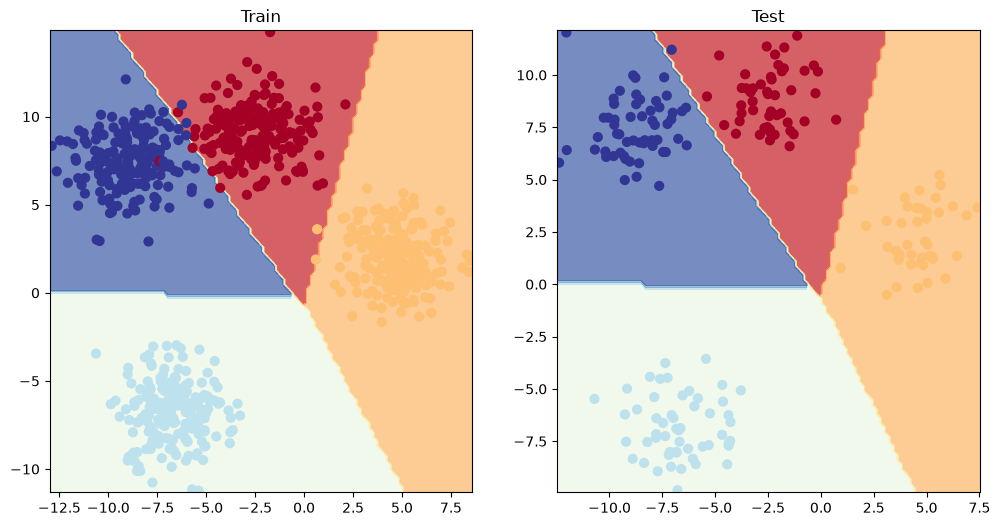

In [128]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_4,X_blobs_train, y_blobs_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_4,X_blobs_test, y_blobs_test)

# 9. Một số metric về classification
https://towardsdatascience.com/10-must-know-classification-metrics-for-machine-learning-2ce3a4ad256e/